In [1]:
import pandas as pd
df=pd.read_csv('../data/raw_data.csv')
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [3]:
df.isnull().sum()

index               0
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
df = df.drop(columns=['index'])

In [5]:
df=df.dropna(subset=['CustomerID'])

In [8]:
df["Description"]=df["Description"].fillna("Unknown")


In [15]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [21]:
df = df.copy()
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [22]:
df = df.drop_duplicates()

In [23]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [24]:
df.shape

(392692, 9)

### RFM Feature Engineering


In [25]:
# defining referrence date for recency calculation
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [26]:
# creating RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [27]:
# renaming columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [28]:
# reset index 
rfm = rfm.reset_index()

In [29]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [31]:
# removing customers with zero or negative monetary value(outliers)
rfm = rfm[(rfm['Monetary'] > 0)]

Customers with low recency values are more recently active.
Customers with higher frequency and monetary values contribute more to business revenue.

### Data Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [35]:
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


In [36]:
# Elbow method to find optimal number of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

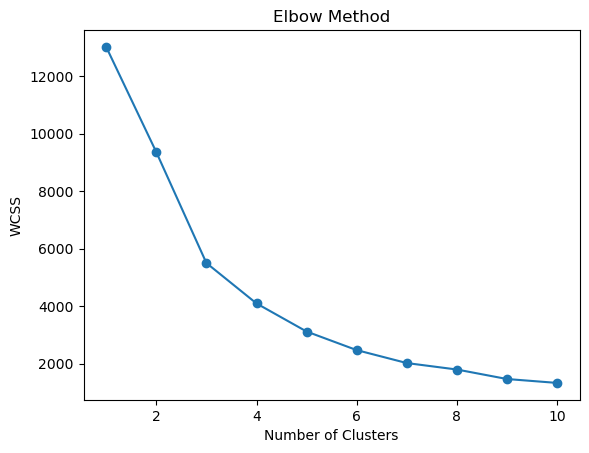

In [38]:
# ploting  elbow curve
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

#### Aplying K-means

In [40]:
# Training model 
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [41]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,1
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [43]:
# cluster count
rfm['Cluster'].value_counts()

Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64

In [44]:
# Analyze Clusters
rfm.groupby('Cluster').mean()

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15282.157846,40.983906,4.852677,2005.830431
1,15354.225984,246.023788,1.582800,629.357439
2,15310.642857,7.142857,80.214286,122748.792143


In [45]:
rfm['Customer_Segment'] = rfm['Cluster'].map({
    2: 'High Value',
    0: 'Regular',
    1: 'Low Value'
})

In [46]:
rfm[['CustomerID','Cluster','Customer_Segment']].head()

,CustomerID,Cluster,Customer_Segment
0,12346.0,1,Low Value
1,12347.0,0,Regular
2,12348.0,0,Regular
3,12349.0,0,Regular
4,12350.0,1,Low Value


### Visualization

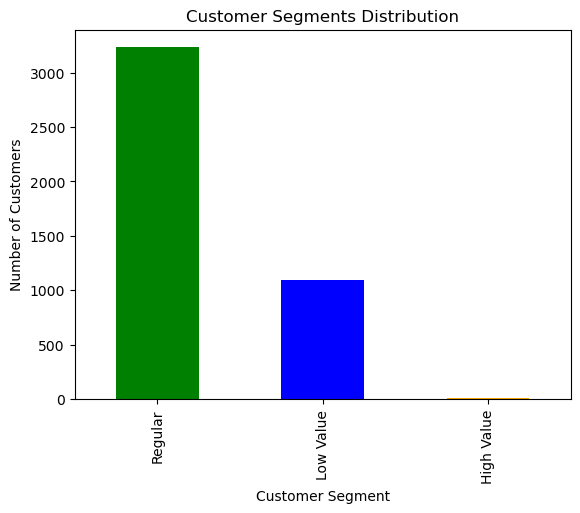

In [62]:
# Customer Segments distribution
rfm['Customer_Segment'].value_counts().plot(kind='bar', color=['green', 'blue', 'orange'])
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segments Distribution')
plt.show()

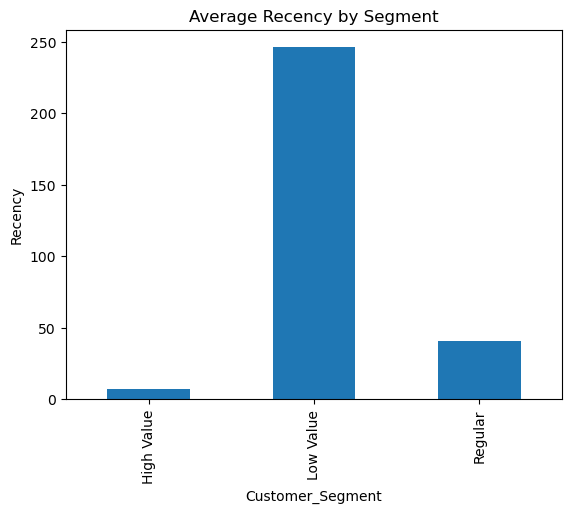

In [66]:
# Recency by segment
rfm.groupby('Customer_Segment')['Recency'].mean().plot(kind='bar')
plt.title('Average Recency by Segment')
plt.ylabel('Recency')
plt.show()

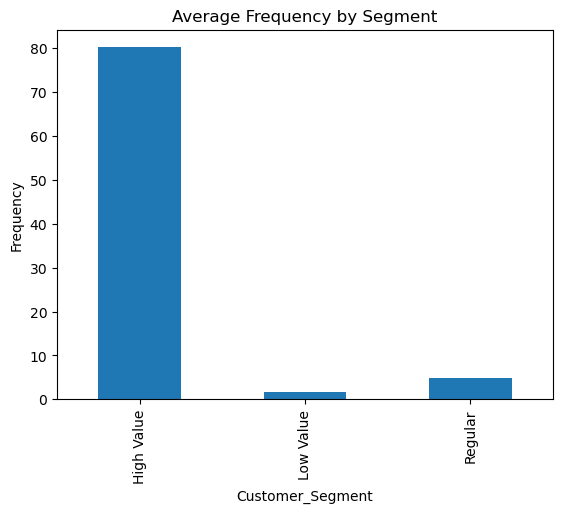

In [67]:
# Frequency by segment
rfm.groupby('Customer_Segment')['Frequency'].mean().plot(kind='bar')
plt.title('Average Frequency by Segment')   
plt.ylabel('Frequency')
plt.show()

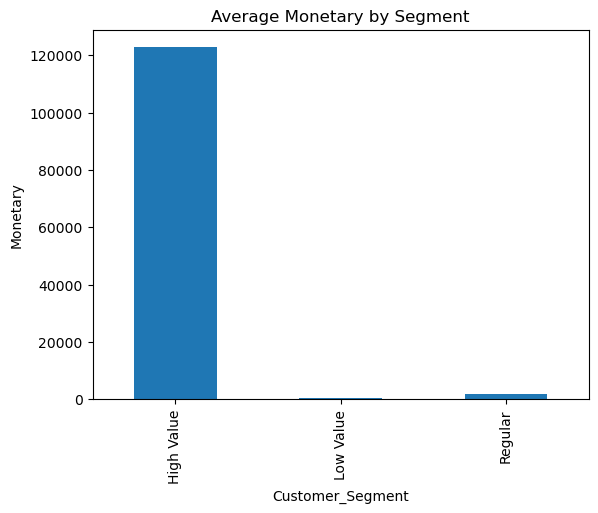

In [68]:
# Monetary by segment
rfm.groupby('Customer_Segment')['Monetary'].mean().plot(kind='bar')
plt.title('Average Monetary by Segment')
plt.ylabel('Monetary')
plt.show()

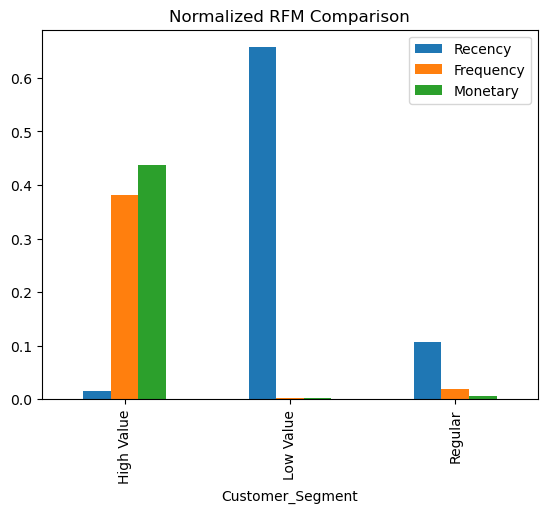

In [63]:
## normalized data for visualization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
rfm_normalized = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

rfm_norm = pd.DataFrame(rfm_normalized, columns=['Recency','Frequency','Monetary'])

# RFM comparison by cluster
rfm_norm['Customer_Segment'] = rfm['Customer_Segment']

rfm_norm.groupby('Customer_Segment').mean().plot(kind='bar')
plt.title('Normalized RFM Comparison')
plt.show()

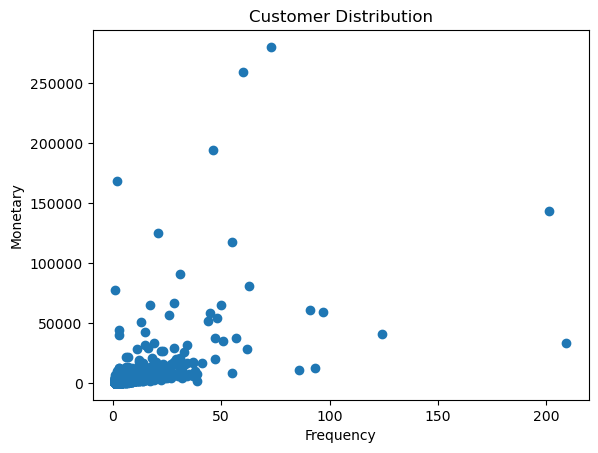

In [64]:
# Scatter plot of frequency vs Monetary 
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Distribution')
plt.show()

In [65]:
# exporting data for further analysis
rfm.to_csv("../data/rfm_output.csv", index=False)